# Chapter 6: Multiple Linear Regression 

## To receive credit, your answers must be based on the instructor's lectures, the example code provided by the instructor, and textbooks for the course, not any other sources such as the Internet, AI tools, or other people. Set random_state=1 wherever needed for this assignment.

In [1]:
# import required functionality for this chapter
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV, Lasso, RidgeCV, Ridge, ElasticNetCV, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from sklearn.pipeline import Pipeline
import matplotlib.pylab as plt
import seaborn as sns
%matplotlib inline

# Problem 1 Predicting Airfare on New Routes.

The following problem takes place in the United States in the late 1990s, when many major US cities were facing issues with airport congestion, partly as a result of the 1978 deregulation of airlines. Both fares and routes were freed from regulation, and low-fare carriers such as Southwest (SW) began competing on existing routes and starting nonstop service on routes that previously lacked it. Building completely new airports is generally not feasible, but sometimes decommissioned military bases or smaller municipal airports can be reconfgured as regional or larger commercial airports. There are numerous players and interests involved in the issue (airlines, city, state and federal authorities, civic groups, the military, airport operators), and an aviation consulting firm is seeking advisory contracts with these players. The firm needs predictive models to support its consulting service. One thing the firm might want to be able to predict is fares, in the event a new airport is brought into service. The firm starts with the file Airfares.csv, which contains real data that were collected between Q3-1996 and Q2-1997. The variables in these data are listed in Table 6.13, and are believed to be important in predicting FARE. Some airport-to-airport data are available, but most data are at the city-to-city level. One question that will be of interest in the analysis is the eﬀect that the presence or absence of Southwest has on FARE.

### Description of Variables for airfares data
<pre>
1.      S_CODE: starting airport’s code	
2.      S_CITY: starting city	
3.      E_CODE: ending airport’s code	
4.      E_CITY: ending city	
5.      COUPON: average number of coupons (a one-coupon flight is a non-stop flight, a two-coupon 
          flight is a one stop flight, etc.) for that route	
6.      NEW: number of new carriers entering that route between Q3-96 and Q2-97	
7.      VACATION: whether a vacation route (Yes) or not (No); Florida and Las Vegas routes are 
          generally considered vacation routes	
8.      SW: whether Southwest Airlines serves that route (Yes) or not (No)	
9.      HI: Herfindel Index – measure of market concentration (refer to BMGT 681)	
10.     S_INCOME: starting city’s average personal income	
11.     E_INCOME: ending city’s average personal income	
12.     S_POP: starting city’s population	
13.     E_POP: ending city’s population	
14.     SLOT: whether either endpoint airport is slot controlled or not; this is a measure of airport 
          congestion	
15.     GATE: whether either endpoint airport has gate constraints or not; this is another measure of 
          airport congestion	
16.     DISTANCE: distance between two endpoint airports in miles	
17.     PAX: number of passengers on that route during period of data collection	
18.     FARE: average fare on that route
</pre>


In [110]:
# load the data and review
airfares = pd.read_csv('~/DS110/data/Airfares.csv')

__a.__ Explore the numerical predictors and response (FARE) by creating a correlation table and examining some scatterplots between FARE and those predictors. What seems to be the best single predictor of FARE?

In [111]:
num_vars = airfares.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr_matrix = num_vars.corr()

print(corr_matrix)

            COUPON       NEW        HI  S_INCOME  E_INCOME     S_POP  \
COUPON    1.000000  0.020223 -0.347252 -0.088403  0.046889 -0.107763   
NEW       0.020223  1.000000  0.054147  0.026597  0.113377 -0.016672   
HI       -0.347252  0.054147  1.000000 -0.027382  0.082393 -0.172495   
S_INCOME -0.088403  0.026597 -0.027382  1.000000 -0.138864  0.517187   
E_INCOME  0.046889  0.113377  0.082393 -0.138864  1.000000 -0.144059   
S_POP    -0.107763 -0.016672 -0.172495  0.517187 -0.144059  1.000000   
E_POP     0.094970  0.058568 -0.062456 -0.272280  0.458418 -0.280143   
DISTANCE  0.746805  0.080965 -0.312375  0.028153  0.176531  0.018437   
PAX      -0.336974  0.010495 -0.168961  0.138197  0.259961  0.284611   
FARE      0.496537  0.091730  0.025195  0.209135  0.326092  0.145097   

             E_POP  DISTANCE       PAX      FARE  
COUPON    0.094970  0.746805 -0.336974  0.496537  
NEW       0.058568  0.080965  0.010495  0.091730  
HI       -0.062456 -0.312375 -0.168961  0.025195  
S_I

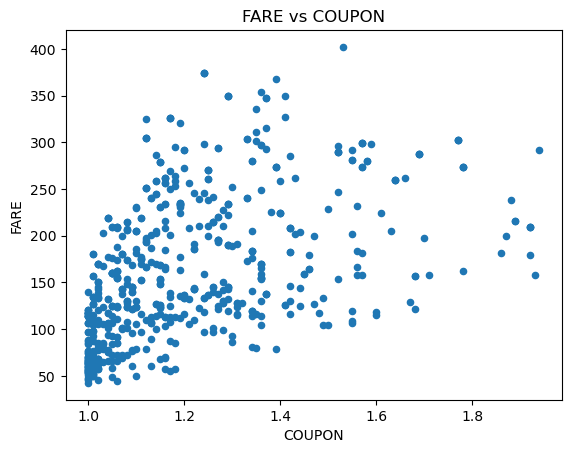

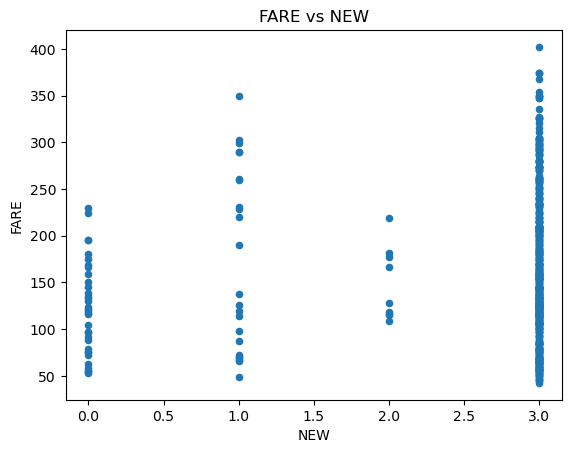

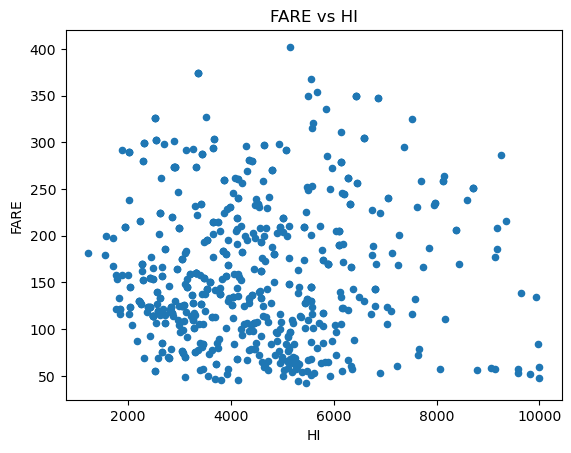

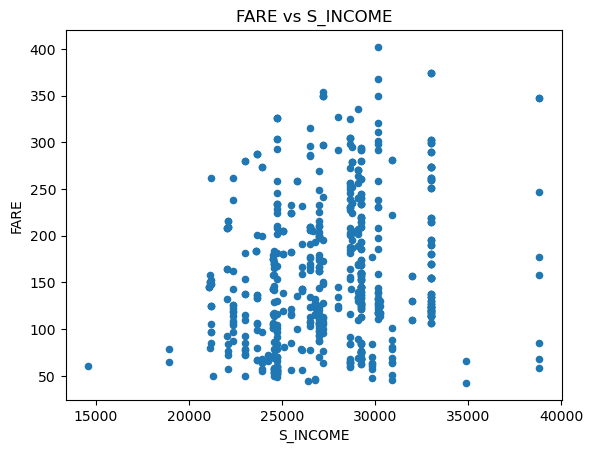

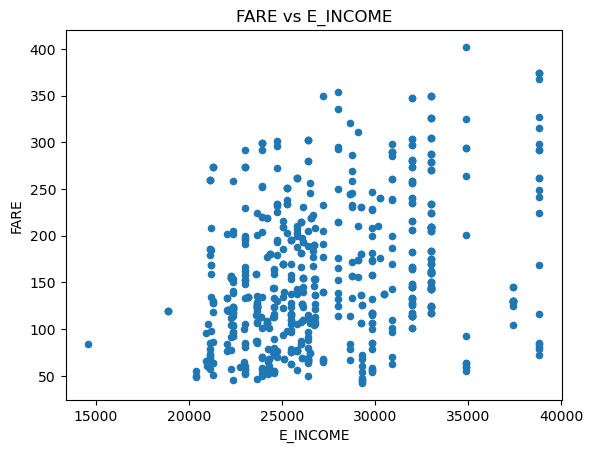

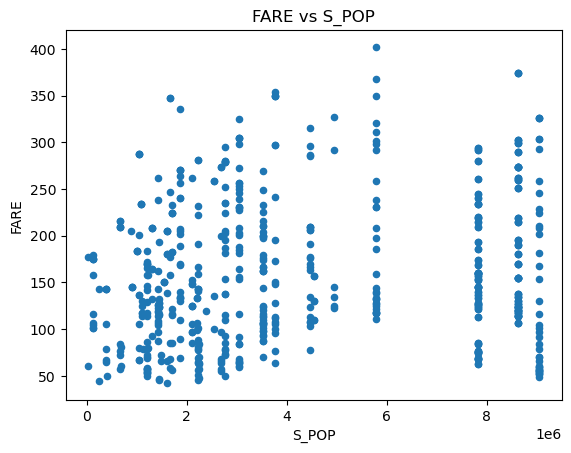

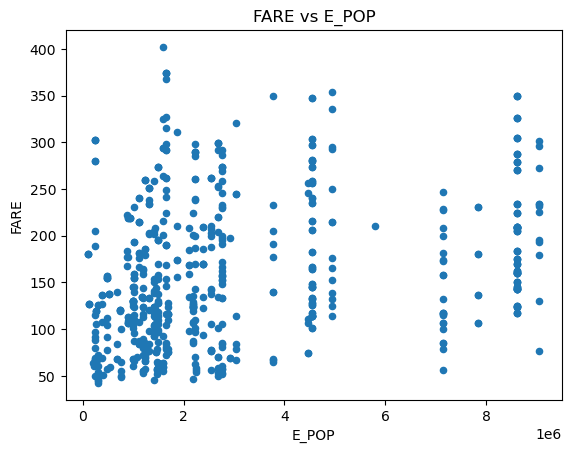

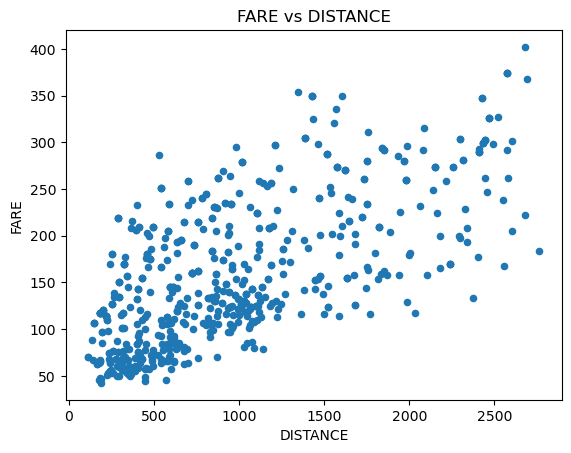

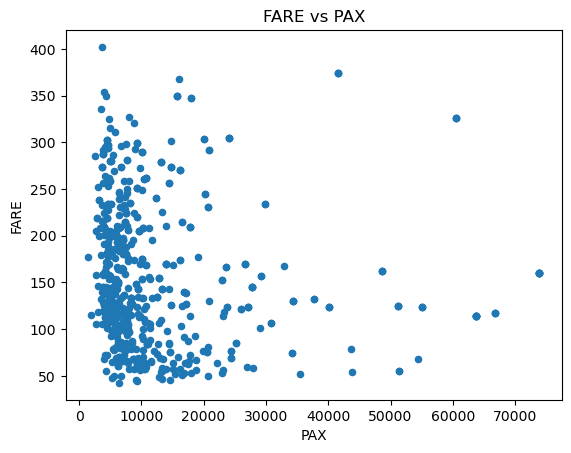

In [112]:
predictors = num_vars.columns.drop('FARE')

for col in predictors:
    ax = airfares.plot.scatter(x=col, y='FARE')
    ax.set_title(f'FARE vs {col}')
    plt.show()

The best single predictor of `FARE` is `DISTANCE`, because it has the highest correlation (0.67) with `FARE` and shows the clearest linear relationship in scatterplots. This indicates that airfare increases strongly and consistently with flight distance compared to any other variable in the dataset.

__b.__ Explore the categorical predictors (excluding the first four) by computing the percentage of ﬂights in each category. Create a pivot table with the average fare in each category. Which categorical predictor seems best for predicting FARE?

In [113]:
cat_vars = ['VACATION','SW','SLOT','GATE']

for col in cat_vars:
    pivot = airfares.pivot_table(values='FARE', index=col, aggfunc='mean')
    print(f"\nAverage FARE by {col}:")
    print(pivot)


Average FARE by VACATION:
                FARE
VACATION            
No        173.552500
Yes       125.980882

Average FARE by SW:
           FARE
SW             
No   188.182793
Yes   98.382268

Average FARE by SLOT:
                  FARE
SLOT                  
Controlled  186.059396
Free        150.825680

Average FARE by GATE:
                   FARE
GATE                   
Constrained  193.129032
Free         153.095953


The best categorical predictor of `FARE` is `SW` (Southwest Airlines presence). This is because it shows the largest difference in average fares between categories: routes without Southwest have an average fare of 188.18, while those with Southwest have a much lower average fare of 98.38. This strong reduction indicates that Southwest’s presence has a major  effect on lowering prices. Other variables such as `VACATION`, `SLOT`, and `GATE` also vary slightly based on fares, but their effects are smaller compared to `SW`.

__c.__ Find a model for predicting the average fare on a new route:

__c.i.__ Convert categorical variables (e.g., SW) into dummy variables. Then, partition the data into training and validation sets. The model will be fit to the training data and evaluated on the validation set.

In [114]:
# Drop identifiers
airfares = airfares.drop(columns=['S_CODE','S_CITY','E_CODE','E_CITY'])

# Convert categorical variables to dummies
airfares = pd.get_dummies(airfares, drop_first=True)

bool_cols = airfares.select_dtypes(include=['bool']).columns
airfares[bool_cols] = airfares[bool_cols].astype(int)

airfares = airfares.astype(float)

# Define X and y
X = airfares.drop(columns=['FARE'])
y = airfares['FARE']

# Partition 60% train, 40% test
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

__c.ii.__ Use stepwise regression to reduce the number of predictors. You can ignore the frst four predictors (S_CODE, S_CITY, E_CODE, E_CITY). Report the estimated model selected.

In [115]:
def forward_selection(X, y):
    remaining = list(X.columns)
    selected = []
    current_aic = float('inf')

    while remaining:
        aic_candidates = []

        for candidate in remaining:
            model = sm.OLS(y, sm.add_constant(X[selected + [candidate]])).fit()
            aic_candidates.append((model.aic, candidate))

        aic_candidates.sort()
        best_aic, best_var = aic_candidates[0]

        if best_aic < current_aic:
            remaining.remove(best_var)
            selected.append(best_var)
            current_aic = best_aic
        else:
            break

    return selected

In [116]:
stepwise_vars = forward_selection(train_X, train_y)

stepwise_model = sm.OLS(
    train_y,
    sm.add_constant(train_X[stepwise_vars])
).fit()

print(stepwise_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   FARE   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     131.2
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          3.06e-115
Time:                        23:40:15   Log-Likelihood:                -1898.9
No. Observations:                 382   AIC:                             3820.
Df Residuals:                     371   BIC:                             3863.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           52.8910     16.595      3.187   

__c.iii.__ Repeat (ii) using exhaustive search instead of stepwise regression. Compare the resulting best model to the one you obtained in (ii) in terms of the predictors that are in the model.

In [3]:
def best_subset_selection(X, y):
    X_cols = list(X.columns)
    p = len(X_cols)

    best_aic = np.inf
    best_model = None
    best_features = None
    
    for k in range(1, p + 1):
        def generate_subsets(n, k, start=0, path=[]):
            if len(path) == k:
                yield path
                return
            for i in range(start, n):
                yield from generate_subsets(n, k, i + 1, path + [i])

        for subset_idx in generate_subsets(p, k):
            subset_cols = [X_cols[i] for i in subset_idx]

            model = sm.OLS(y, sm.add_constant(X[subset_cols])).fit()

            if model.aic < best_aic:
                best_aic = model.aic
                best_model = model
                best_features = subset_cols

    return best_features, best_model

In [118]:
best_features, best_model = best_subset_selection(train_X, train_y)

print(best_features)
print(best_model.summary())

['HI', 'E_INCOME', 'S_POP', 'E_POP', 'DISTANCE', 'PAX', 'VACATION_Yes', 'SW_Yes', 'SLOT_Free', 'GATE_Free']
                            OLS Regression Results                            
Dep. Variable:                   FARE   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     131.2
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          3.06e-115
Time:                        23:40:32   Log-Likelihood:                -1898.9
No. Observations:                 382   AIC:                             3820.
Df Residuals:                     371   BIC:                             3863.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------

__c.iv.__ Repeat (ii) using Lasso regression. Compare the resulting best model for Lasso regression to the one you obtained in (ii) in terms of the predictors that are in the model.

In [119]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_X)
X_valid_scaled = scaler.transform(valid_X)

lasso = LassoCV(cv=5, random_state=1)
lasso.fit(X_train_scaled, train_y)

lasso_coeffs = pd.Series(lasso.coef_, index=train_X.columns)

selected_lasso_vars = lasso_coeffs[lasso_coeffs != 0].index.tolist()

In [120]:
lasso_model = sm.OLS(train_y, sm.add_constant(train_X[selected_lasso_vars])).fit()
print(lasso_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   FARE   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     101.0
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          1.21e-112
Time:                        23:40:32   Log-Likelihood:                -1897.6
No. Observations:                 382   AIC:                             3823.
Df Residuals:                     368   BIC:                             3878.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           52.9728     35.288      1.501   

__c.v.__ Compare the predictive accuracy of both models (ii), (iii), and (iv) using measures such as RMSE and average error, lift and gains charts.

In [121]:
def rmse(model, X, y):
    pred = model.predict(sm.add_constant(X))
    return np.sqrt(mean_squared_error(y, pred))

In [122]:
rmse_step = rmse(stepwise_model, valid_X[stepwise_vars], valid_y)
rmse_best = rmse(best_model, valid_X[list(best_features)], valid_y)
rmse_lasso = rmse(lasso_model, valid_X[selected_lasso_vars], valid_y)

print("Stepwise RMSE:", rmse_step)
print("Exhaustive RMSE:", rmse_best)
print("Lasso RMSE:", rmse_lasso)

Stepwise RMSE: 36.11288877166283
Exhaustive RMSE: 36.11288877080553
Lasso RMSE: 36.00021339544545


__c.vi.__ Using model (iii), predict the average fare on a route with the following characteristics: COUPON = 1.202, NEW = 3, VACATION = No, SW = No, HI = 4442.141, S_INCOME = 28,760, E_INCOME = 27,664, S_POP = 4,557,004, E_POP = 3,195,503, SLOT = Free, GATE = Free, PAX = 12,782, DISTANCE = 1976 miles.

In [123]:
model_features = best_model.model.exog_names

new_route = pd.DataFrame([{
    "COUPON": 1.202,
    "NEW": 3,
    "HI": 4442.141,
    "S_INCOME": 28760,
    "E_INCOME": 27664,
    "S_POP": 4557004,
    "E_POP": 3195503,
    "DISTANCE": 1976,
    "PAX": 12782,
    "VACATION_Yes": 0,
    "SW_Yes": 0,
    "SLOT_Free": 1,
    "GATE_Free": 1
}])

X_new = new_route.copy()

for col in model_features:
    if col not in X_new.columns:
        X_new[col] = 0

X_new = X_new[model_features]

X_new = sm.add_constant(X_new)

In [124]:
fare_pred = best_model.predict(X_new)

fare_pred

0    198.830531
dtype: float64

__c.vii.__ Predict the reduction in average fare on the route in (vi) if Southwest decides to cover this route [using model (iii)].

In [127]:
model_cols = best_model.model.exog_names

route_no_sw = new_route.copy()
route_no_sw["SW_Yes"] = 0

route_yes_sw = new_route.copy()
route_yes_sw["SW_Yes"] = 1

def align(X, cols):
    X = X.copy()
    
    for c in cols:
        if c not in X.columns:
            X[c] = 0
            
    return X[cols]

In [130]:
X0 = sm.add_constant(align(route_no_sw, model_cols))
X1 = sm.add_constant(align(route_yes_sw, model_cols))

fare_no_sw = best_model.predict(X0)[0]
fare_yes_sw = best_model.predict(X1)[0]

sw_effect = fare_no_sw - fare_yes_sw

print(fare_no_sw)
print(fare_yes_sw)
print(sw_effect)

198.83053097084505
155.7992589196991
43.03127205114595


__c.viii.__ In reality, which of the factors will not be available for predicting the average fare from a new airport (i.e., before ﬂights start operating on those routes)? Which ones can be estimated? How?

Not available:
* PAX (passenger volume)

Can be estimated:
* DISTANCE is known
* INCOME, POP can be found with census data
* SLOT/GATE is known via airport constraints

__c.ix.__ Select a model that includes only factors that are available before ﬂights begin to operate on the new route. Use an exhaustive search to find such a model.

In [132]:
pre_train_X = train_X.drop(columns=["PAX"])
pre_valid_X = valid_X.drop(columns=["PAX"])

pre_features, pre_model = best_subset_selection(pre_train_X, train_y)

print(pre_features)
print(pre_model.summary())

['HI', 'S_POP', 'E_POP', 'DISTANCE', 'VACATION_Yes', 'SW_Yes', 'SLOT_Free', 'GATE_Free']
                            OLS Regression Results                            
Dep. Variable:                   FARE   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     150.2
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          1.15e-111
Time:                        23:43:18   Log-Likelihood:                -1912.7
No. Observations:                 382   AIC:                             3843.
Df Residuals:                     373   BIC:                             3879.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

__c.x.__ Use the model in (ix) to predict the average fare on a route with characteristics COUPON = 1.202, NEW = 3, VACATION = No, SW = No, HI = 4442.141, S_INCOME = 28,760, E_INCOME = 27,664, S_ POP = 4,557,004, E_POP = 3,195,503, SLOT = Free, GATE = Free, PAX = 12782, DISTANCE = 1976 miles.

In [133]:
model_cols = pre_model.model.exog_names.copy()

new_route = pd.DataFrame([{
    "COUPON": 1.202,
    "NEW": 3,
    "HI": 4442.141,
    "S_INCOME": 28760,
    "E_INCOME": 27664,
    "S_POP": 4557004,
    "E_POP": 3195503,
    "DISTANCE": 1976,
    "VACATION_Yes": 0,
    "SW_Yes": 0,
    "SLOT_Free": 1,
    "GATE_Free": 1
}])

X_new = new_route.copy()

for col in model_cols:
    if col not in X_new.columns:
        X_new[col] = 0

X_new = X_new[model_cols]

X_new = sm.add_constant(X_new)

In [134]:
fare_pred = pre_model.predict(X_new)

fare_pred

0    177.239038
dtype: float64

__c.xi.__ Compare the predictive accuracy of this model with model (iii). Is this model good enough, or is it worthwhile reevaluating the model once ﬂights begin on the new route?

In [135]:
rmse_model3 = rmse(best_model, valid_X[list(best_features)], valid_y)

In [136]:
rmse_model9 = rmse(pre_model, pre_valid_X[list(pre_features)], valid_y)

In [137]:
print(rmse_model3)
print(rmse_model9)

36.11288877080553
37.14503777177097


__d.__ In competitive industries, a new entrant with a novel business plan can have a disruptive eﬀect on existing firms. If a new entrant’s business model is sustainable, other players are forced to respond by changing their business practices. If the goal of the analysis was to evaluate the eﬀect of Southwest Airlines’ presence on the airline industry rather than predicting fares on new routes, how would the analysis be diﬀerent? Describe technical and conceptual aspects.

We want to build a predictive model where the goal is accurate fare prediction. We can use metrics such as RMSE and model fit to evaluate model performance. Using these metrics we can select a final regression or lasso model that generalizes to new data best.

# Problem 2 Lasso and Ridge Regression

## (a) Lasso

In [139]:
car_df = pd.read_csv('~/DS110/data/ToyotaCorolla.csv')

# create a list of predictor variables by remvoing output variables and text columns
excludeColumns = ('Price', 'Id', 'Model', 'Fuel_Type', 'Color')
# list comprehension
predictors = [s for s in car_df.columns if s not in excludeColumns]
outcome = 'Price'

# partition data
X = car_df[predictors]
y = car_df[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

### Standardize predictors based on training data

In [142]:
scaler = StandardScaler()

train_X_std = scaler.fit_transform(train_X)
valid_X_std = scaler.transform(valid_X)

### Fit LassoCV to standardized predictors by filling in the missing parts below

In [143]:
# see https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html
lasso_cv = LassoCV(max_iter=10000, alphas=np.logspace(-3, 3, 100), random_state=1, cv=5)

In [153]:
lasso_cv = LassoCV(
    max_iter=10000,
    alphas=np.logspace(-3, 3, 100),
    random_state=1,
    cv=5
)

In [154]:
lasso_cv.fit(train_X_std, train_y)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

LassoCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        cv=5, max_iter=10000, random_state=1)

### Find Root Mean Squared Error (RMSE) by filling in the missing parts below

In [155]:
pred = lasso_cv.predict(valid_X_std)

In [156]:
rmse = np.sqrt(mean_squared_error(valid_y, pred))
rmse

np.float64(1305.7134829105607)

### Print out the chosen alpha (i.e., lambda) and coefficients

In [157]:
print('Lasso-CV chosen regularization: ', lasso_cv.alpha_)
print(lasso_cv.coef_)

Lasso-CV chosen regularization:  8.697490026177835
[-337.36508447   -0.         1920.07238971 -661.03352604  432.20240202
   -9.45228437  119.07175278 -223.177054    102.66776986    0.
    8.84752225  464.78439023  511.69587341   70.13559311   86.92404532
  184.47686345  -78.97043075   65.8399709    -7.43990041   44.53726956
  580.39748876 -120.31874953   81.75247836   82.9300798   119.78942032
  -67.39547953    5.72856825   -9.36115758  182.64052367   -9.1967657
  121.54125716    0.           -5.47590871  -68.00559833]


### Fit Lasso by plugging in the chosen alpha below into Lasso()

In [159]:
lasso = Lasso(max_iter=10000,random_state=1, alpha=8.697490026177835)
lasso.fit(train_X_std, train_y)

,alpha,8.697490026177835
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,1
,selection,'cyclic'


### Print out the Lasso coefficients

In [160]:
print(lasso.coef_)

[-337.36508447   -0.         1920.07238971 -661.03352604  432.20240202
   -9.45228437  119.07175278 -223.177054    102.66776986    0.
    8.84752225  464.78439023  511.69587341   70.13559311   86.92404532
  184.47686345  -78.97043075   65.8399709    -7.43990041   44.53726956
  580.39748876 -120.31874953   81.75247836   82.9300798   119.78942032
  -67.39547953    5.72856825   -9.36115758  182.64052367   -9.1967657
  121.54125716    0.           -5.47590871  -68.00559833]


### Find Root Mean Squared Error (RMSE) by filling in the missing parts below

In [162]:
regressionSummary(valid_y, lasso.predict())

NameError: name 'regressionSummary' is not defined

In [163]:
rmse = np.sqrt(mean_squared_error(valid_y, pred))
rmse

np.float64(1305.7134829105607)

## Use Pipeline to fit Lasso

In [165]:
car_df = pd.read_csv('~/DS110/data/ToyotaCorolla.csv')

# create a list of predictor variables by remvoing output variables and text columns
excludeColumns = ('Price', 'Id', 'Model', 'Fuel_Type', 'Color')
# list comprehension
predictors = [s for s in car_df.columns if s not in excludeColumns]
outcome = 'Price'

# partition data
X = car_df[predictors]
y = car_df[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

In [172]:
# see https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html
# default choose one alpha from 100 different values of the regularization strength parameter α),
# logarithmically spaced between a maximum and minimum value that it computes from your data.
lasso_cv = Pipeline([
    ['normalize', StandardScaler(with_mean=True)],
    ['model', LassoCV(max_iter=10000, alphas=np.logspace(-3, 3, 100), random_state=1, cv=5)],
])
lasso_cv.fit(train_X, train_y)

rmse = np.sqrt(mean_squared_error(valid_y, lasso_cv.predict(valid_X)))
print(rmse)

print('Lasso-CV chosen regularization: ', lasso_cv['model'].alpha_)
print(lasso_cv['model'].coef_)

1305.7134829105607
Lasso-CV chosen regularization:  8.697490026177835
[-337.36508447   -0.         1920.07238971 -661.03352604  432.20240202
   -9.45228437  119.07175278 -223.177054    102.66776986    0.
    8.84752225  464.78439023  511.69587341   70.13559311   86.92404532
  184.47686345  -78.97043075   65.8399709    -7.43990041   44.53726956
  580.39748876 -120.31874953   81.75247836   82.9300798   119.78942032
  -67.39547953    5.72856825   -9.36115758  182.64052367   -9.1967657
  121.54125716    0.           -5.47590871  -68.00559833]


### Fit Lasso again by plugging in the chosen alpha and compare results

In [173]:
lasso = Pipeline([
    ['normalize', StandardScaler(with_mean=True)],
    ['model', Lasso(max_iter=10000, random_state=1, alpha=8.697490026177835)],
])
lasso.fit(train_X, train_y)
print(lasso['model'].coef_)

rmse = np.sqrt(mean_squared_error(valid_y, lasso.predict(valid_X)))
print(rmse)

[-337.36508447   -0.         1920.07238971 -661.03352604  432.20240202
   -9.45228437  119.07175278 -223.177054    102.66776986    0.
    8.84752225  464.78439023  511.69587341   70.13559311   86.92404532
  184.47686345  -78.97043075   65.8399709    -7.43990041   44.53726956
  580.39748876 -120.31874953   81.75247836   82.9300798   119.78942032
  -67.39547953    5.72856825   -9.36115758  182.64052367   -9.1967657
  121.54125716    0.           -5.47590871  -68.00559833]
1305.7134829105607


## (b) Ridge Regression

In [174]:
car_df = pd.read_csv('~/DS110/data/ToyotaCorolla.csv')

# create a list of predictor variables by remvoing output variables and text columns
excludeColumns = ('Price', 'Id', 'Model', 'Fuel_Type', 'Color')
# list comprehension
predictors = [s for s in car_df.columns if s not in excludeColumns]
outcome = 'Price'

# partition data
X = car_df[predictors]
y = car_df[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

### Standardize predictors based on training data

In [175]:
scaler = StandardScaler()

train_X_std = scaler.fit_transform(train_X)
valid_X_std = scaler.transform(valid_X)

### Fit RidgeCV() to standardized predictors by filling in the missing parts below

In [179]:
# see https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html#sklearn.linear_model.RidgeCV
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
# default alphas=(0.1, 1.0, 10.0), only 3 values
# It's better to choose a range that spans several orders of magnitude, e.g., 
# alphas=np.logspace(-3, 3, 100) or 100 values of alpha ranging from 0.001 to 1000 spaced logarithmically.

ridge_cv.fit(train_X_std, train_y)

ValueError: operands could not be broadcast together with shapes (100,) (3,) 

ValueError: operands could not be broadcast together with shapes (100,) (3,) 

RidgeCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        cv=5)

In [180]:
pred = ridge_cv.predict(valid_X_std)

### Find Root Mean Squared Error (RMSE) by filling in the missing parts below

In [190]:
rmse = np.sqrt(mean_squared_error(valid_y, ridge_cv.predict(valid_X_std)))
rmse

np.float64(1255.5545507604618)

### Print out the chosen alpha and coefficients

In [191]:
print('Ridge-CV chosen regularization: ', ridge_cv.alpha_)
print(ridge_cv.coef_)

Ridge-CV chosen regularization:  46.41588833612782
[-1034.06807407  -133.60178882  1067.5337909   -674.66716662
   395.87519026   -24.49210678   123.65918239  -191.5027657
   119.76751523     0.            26.63581314   432.49948733
   521.14951126    88.53875788    86.26327365   196.44242359
   -59.00726465    90.44135843    -7.03469514    72.56937361
   589.40295983   -42.66549478   120.30661265    92.63438843
   126.29309297   -84.74868081    26.60557217   -36.80012314
   193.70314384   -23.77733349   127.6111545     -2.4702994
   -13.55652631   -90.73135283]


### Fit Ridge Regression by plugging in the chosen alpha below into Ridge()

In [192]:
ridge = Ridge(max_iter=10000,random_state=1, alpha=46.41588833612782)
ridge.fit(train_X_std, train_y)

,alpha,46.41588833612782
,fit_intercept,True
,copy_X,True
,max_iter,10000
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,1


### Print out the Ridge Regression coefficients

In [193]:
print(ridge.coef_)

[-1034.06807407  -133.60178882  1067.5337909   -674.66716662
   395.87519026   -24.49210678   123.65918239  -191.5027657
   119.76751523     0.            26.63581314   432.49948733
   521.14951126    88.53875788    86.26327365   196.44242359
   -59.00726465    90.44135843    -7.03469514    72.56937361
   589.40295983   -42.66549478   120.30661265    92.63438843
   126.29309297   -84.74868081    26.60557217   -36.80012314
   193.70314384   -23.77733349   127.6111545     -2.4702994
   -13.55652631   -90.73135283]


### Find Root Mean Squared Error (RMSE) by filling in the missing parts below

In [195]:
rmse = np.sqrt(mean_squared_error(valid_y, ridge.predict(valid_X_std)))
rmse

np.float64(1255.5545507604618)

## Use Pipeline to fit Ridge Regression

In [197]:
car_df = pd.read_csv('~/DS110/data/ToyotaCorolla.csv')

# create a list of predictor variables by remvoing output variables and text columns
excludeColumns = ('Price', 'Id', 'Model', 'Fuel_Type', 'Color')
# list comprehension
predictors = [s for s in car_df.columns if s not in excludeColumns]
outcome = 'Price'

# partition data
X = car_df[predictors]
y = car_df[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

In [199]:
# see https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html#sklearn.linear_model.RidgeCV
ridge_cv = Pipeline([
    ['normalize', StandardScaler(with_mean=True)],
    ['model', RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)],
])
ridge_cv.fit(train_X, train_y)

rmse = np.sqrt(mean_squared_error(valid_y, ridge_cv.predict(valid_X_std)))
rmse

print('Ridge-CV chosen regularization: ', ridge_cv['model'].alpha_)
print(ridge_cv['model'].coef_)

Ridge-CV chosen regularization:  46.41588833612782
[-1034.06807407  -133.60178882  1067.5337909   -674.66716662
   395.87519026   -24.49210678   123.65918239  -191.5027657
   119.76751523     0.            26.63581314   432.49948733
   521.14951126    88.53875788    86.26327365   196.44242359
   -59.00726465    90.44135843    -7.03469514    72.56937361
   589.40295983   -42.66549478   120.30661265    92.63438843
   126.29309297   -84.74868081    26.60557217   -36.80012314
   193.70314384   -23.77733349   127.6111545     -2.4702994
   -13.55652631   -90.73135283]


/srv/conda/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Fit Ridge Regression again by plugging in the chosen alpha and compare results

In [204]:
ridge = Pipeline([
    ['normalize', StandardScaler(with_mean=True)],
    ['model', Ridge(max_iter=10000, random_state=1, alpha=46.41588833612782)]
])
ridge.fit(train_X, train_y)
print(ridge['model'].coef_)

rmse = np.sqrt(mean_squared_error(valid_y, ridge.predict(valid_X)))
rmse

[-1034.06807407  -133.60178882  1067.5337909   -674.66716662
   395.87519026   -24.49210678   123.65918239  -191.5027657
   119.76751523     0.            26.63581314   432.49948733
   521.14951126    88.53875788    86.26327365   196.44242359
   -59.00726465    90.44135843    -7.03469514    72.56937361
   589.40295983   -42.66549478   120.30661265    92.63438843
   126.29309297   -84.74868081    26.60557217   -36.80012314
   193.70314384   -23.77733349   127.6111545     -2.4702994
   -13.55652631   -90.73135283]


np.float64(1255.5545507604618)

# Problem 3 Predicting Prices of Used Cars. 

The file _ToyotaCorolla.csv_ contains data on used cars (Toyota Corolla) on sale during late summer of 2004 in the Netherlands. It has 1436 records containing details on 38 attributes, including Price, Age, Kilometers, HP, and other specifcations. The goal is to predict the price of a used Toyota Corolla based on its specifcations. (The example in Section 6.3 is a subset of this dataset.) 

Split the data into training (60%) and validation (40%) datasets. 

Run a multiple linear regression with the outcome variable Price and predictor variables Age_08_04, KM, Fuel_Type, HP, Automatic, Doors, Quarterly_Tax, Mfr_Guarantee, Guarantee_Period, Airco, Automatic_airco, CD_Player, Powered_Windows, Sport_Model, and Tow_Bar.

In [5]:
# load the data
car_df = pd.read_csv('~/DS110/data/ToyotaCorolla.csv')

car_df = car_df.drop(columns=['Id', 'Model', 'Color'])

car_df = pd.get_dummies(car_df, columns=['Fuel_Type'], drop_first=True)

excludeColumns = ('Price',)
predictors = [s for s in car_df.columns if s not in excludeColumns]

X = car_df[predictors]
y = car_df['Price']

X = X.astype(float)

train_X, valid_X, train_y, valid_y = train_test_split(
    X, y, test_size=0.4, random_state=1
)

print(car_df)

      Price  Age_08_04  Mfg_Month  Mfg_Year     KM   HP  Met_Color  Automatic  \
0     13500         23         10      2002  46986   90          1          0   
1     13750         23         10      2002  72937   90          1          0   
2     13950         24          9      2002  41711   90          1          0   
3     14950         26          7      2002  48000   90          0          0   
4     13750         30          3      2002  38500   90          0          0   
...     ...        ...        ...       ...    ...  ...        ...        ...   
1431   7500         69         12      1998  20544   86          1          0   
1432  10845         72          9      1998  19000   86          0          0   
1433   8500         71         10      1998  17016   86          0          0   
1434   7250         70         11      1998  16916   86          1          0   
1435   6950         76          5      1998      1  110          0          0   

        CC  Doors  ...  Rad

In [216]:
train_X_const = sm.add_constant(train_X)

model = sm.OLS(train_y, train_X_const).fit()
print(model.summary())

valid_X_const = sm.add_constant(valid_X)

pred = model.predict(valid_X_const)

rmse = np.sqrt(mean_squared_error(valid_y, pred))
rmse

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     256.8
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:05:05   Log-Likelihood:                -7243.2
No. Observations:                 861   AIC:                         1.456e+04
Df Residuals:                     826   BIC:                         1.472e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Age_08_04          -120.2985      4.48

np.float64(2752.1381059367077)

In [ ]:
train_X_const = sm.add_constant(train_X)
best_features, best_model = best_subset_selection(train_X_const, train_y)

print(best_features)
print(best_model.summary())

__a.__ What appear to be the three or four most important car specifcations for predicting the car’s price?

Age_08_04
* coef = -120.30
* p < 0.001

KM
* coef = -0.0167
* p < 0.001

HP
* coef = 60.46
* p < 0.001

__b.__ Using metrics you consider useful, assess the performance of the model in predicting prices. 

$R^2 = 0.914$. This means the model explains 91.4% of variation, which indicates very strong predictive power. Our $RMSE = 2752$, so the average prediction error is around $2752.

__c.__ Train lasso, ridge, and elastic net regression models by tuning the penalty parameters using 5-fold cross-validation and compare their performance to the multiple linear regression model. 

In [217]:
scaler = StandardScaler()
train_X_std = scaler.fit_transform(train_X)
valid_X_std = scaler.transform(valid_X)

In [218]:
lasso = LassoCV(cv=5, random_state=1)
lasso.fit(train_X_std, train_y)

lasso_pred = lasso.predict(valid_X_std)

In [219]:
ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge.fit(train_X_std, train_y)

ridge_pred = ridge.predict(valid_X_std)

In [222]:
enet = ElasticNetCV(cv=5, random_state=1)
enet.fit(train_X_std, train_y)

enet_pred = enet.predict(valid_X_std)

In [225]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = {
    "OLS": 2752.14,
    "Lasso": rmse(valid_y, lasso_pred),
    "Ridge": rmse(valid_y, ridge_pred),
    "ElasticNet": rmse(valid_y, enet_pred)
}

results

{'OLS': 2752.14,
 'Lasso': np.float64(2516.959793277975),
 'Ridge': np.float64(2467.2077554825605),
 'ElasticNet': np.float64(1846.6558524804905)}